# Spearman-Korrelation – Rangkorrelationskoeffizient

> Quelle: [numiqo.de](https://numiqo.de/tutorial/spearman-korrelation)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **Spearman-Rangkorrelation** (ρ, Spearmans Rho) ist das
nichtparametrische Gegenstück zur Pearson-Korrelation.
Sie basiert auf **Rängen** statt auf Rohdaten.

**Kernidee:** Spearman = Pearson auf den Rängen!

**Formel (ohne Bindungen):**
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2-1)}$$

wobei $d_i = \text{Rang}(x_i) - \text{Rang}(y_i)$ die Rang-Differenz je Paar ist.

**Signifikanztest:**
$$t = \rho \cdot \sqrt{\frac{n-2}{1-\rho^2}}, \quad df = n-2$$

| $|\rho|$ | Stärke |
|---|---|
| 0,0 – 0,1 | Keine Korrelation |
| 0,1 – 0,3 | Gering |
| 0,3 – 0,5 | Mittel |
| 0,5 – 0,7 | Hoch |
| 0,7 – 1,0 | Sehr hoch |

**Wann Spearman statt Pearson?**
- Keine Normalverteilung
- Ordinales Skalenniveau
- Ausreißer vorhanden
- Monotoner, aber nicht linearer Zusammenhang
- Kleine Stichproben

In [1]:
print("Kernel läuft")

Kernel läuft


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr, pearsonr, rankdata

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Reaktionszeit und Alter (n = 8)

**Fragestellung:** Gibt es einen Zusammenhang zwischen Reaktionszeit und Alter?

**Datensatz:**

| Person | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| Reaktionszeit (ms) | 12 | 15 | 18 | 21 | 25 | 28 | 31 | 35 |
| Alter (Jahre) | 20 | 19 | 23 | 25 | 22 | 27 | 29 | 30 |

**Erwartetes numiqo-Ergebnis:** ρ = 0,9, p = 0,002 → signifikant

In [8]:
# numiqo-Datensatz
reaktionszeit = np.array([12, 15, 18, 21, 25, 28, 31, 35], dtype=float)
alter         = np.array([20, 19, 23, 25, 22, 27, 29, 30], dtype=float)
n = len(reaktionszeit)

# Ränge vergeben
rang_rz  = rankdata(reaktionszeit)
rang_alt = rankdata(alter)
d        = rang_rz - rang_alt
d2       = d**2

print("Datensatz mit Rängen")
print("Person  RZ   Alter  Rang_RZ  Rang_Alt  d=R_RZ-R_Alt  d^2")
for i in range(n):
    print(str(i+1) + "       " + str(int(reaktionszeit[i])) +
          "   " + str(int(alter[i])) +
          "     " + str(rang_rz[i]) +
          "        " + str(rang_alt[i]) +
          "        " + str(d[i]) +
          "            " + str(int(d2[i])))
print()
print("Summe d^2 = " + str(int(d2.sum())) + "  (numiqo: 8)")
print()

# Formel (ohne Bindungen)
rho_formel = 1 - (6 * d2.sum()) / (n * (n**2 - 1))

# Pearson auf Rängen (allgemeiner)
rho_pearson, _ = pearsonr(rang_rz, rang_alt)

# scipy spearmanr
rho_sci, p_sci = spearmanr(reaktionszeit, alter)

print("Spearman-Korrelation")
print("rho (Formel):  " + str(round(rho_formel, 4)) + "  (numiqo: 0.9)")
print("rho (Pearson auf Rängen): " + str(round(rho_pearson, 4)))
print("rho (scipy):   " + str(round(rho_sci, 4)))
print("p-Wert:        " + str(round(p_sci, 4)) + "  (numiqo: 0.002)")
print()

def interpret_rho(r):
    ar = abs(r)
    if ar < 0.1: return "keine Korrelation"
    elif ar < 0.3: return "geringe Korrelation"
    elif ar < 0.5: return "mittlere Korrelation"
    elif ar < 0.7: return "hohe Korrelation"
    return "sehr hohe Korrelation"

print("Interpretation: rho=" + str(round(rho_sci, 2)) +
      " -> " + interpret_rho(rho_sci))
print()
print("APA: rs(6) = .90, p = .002")
print("Signifikant! Sehr hohe positive Korrelation zwischen Alter und Reaktionszeit.")

Datensatz mit Rängen
Person  RZ   Alter  Rang_RZ  Rang_Alt  d=R_RZ-R_Alt  d^2
1       12   20     1.0        2.0        -1.0            1
2       15   19     2.0        1.0        1.0            1
3       18   23     3.0        4.0        -1.0            1
4       21   25     4.0        5.0        -1.0            1
5       25   22     5.0        3.0        2.0            4
6       28   27     6.0        6.0        0.0            0
7       31   29     7.0        7.0        0.0            0
8       35   30     8.0        8.0        0.0            0

Summe d^2 = 8  (numiqo: 8)

Spearman-Korrelation
rho (Formel):  0.9048  (numiqo: 0.9)
rho (Pearson auf Rängen): 0.9048
rho (scipy):   0.9048
p-Wert:        0.002  (numiqo: 0.002)

Interpretation: rho=0.9 -> sehr hohe Korrelation

APA: rs(6) = .90, p = .002
Signifikant! Sehr hohe positive Korrelation zwischen Alter und Reaktionszeit.


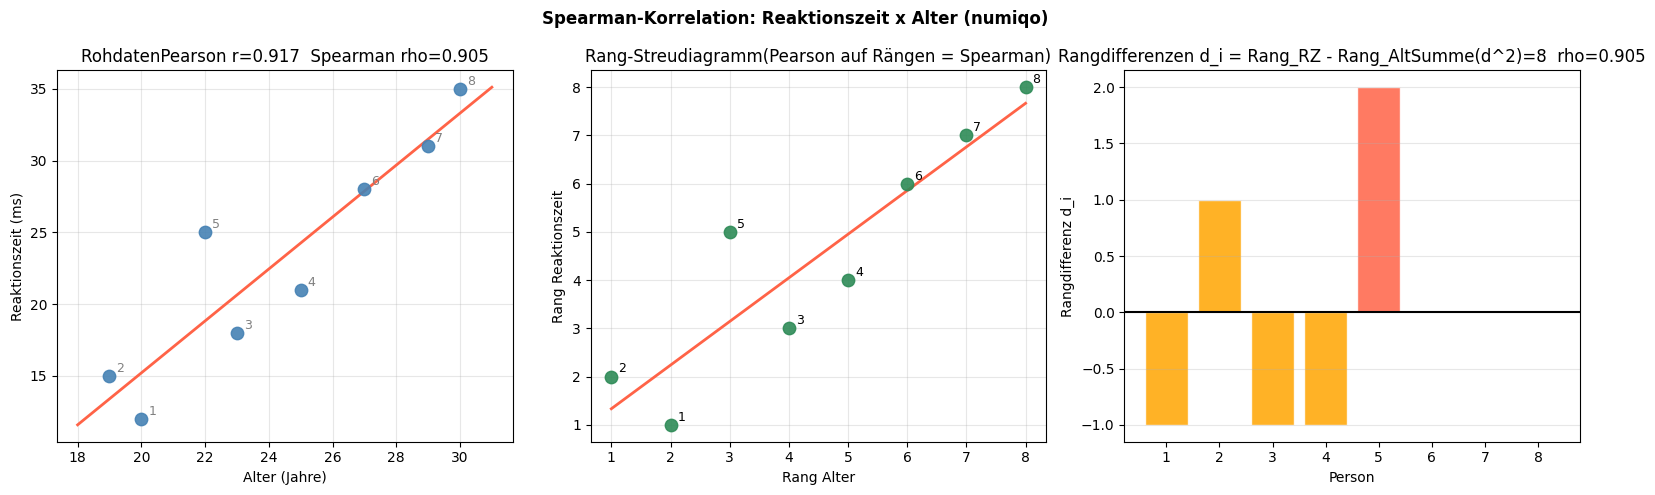

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Spearman-Korrelation: Reaktionszeit x Alter (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Rohdaten vs. Ränge
axes[0].scatter(alter, reaktionszeit, color="steelblue", s=80, alpha=0.9, zorder=3)
for i, (a, rz) in enumerate(zip(alter, reaktionszeit)):
    axes[0].annotate(str(i+1), (a, rz), textcoords="offset points",
                     xytext=(5, 3), fontsize=9, color="gray")
m_r, b_r = np.polyfit(alter, reaktionszeit, 1)
x_l = np.linspace(alter.min()-1, alter.max()+1, 100)
axes[0].plot(x_l, m_r*x_l + b_r, color="tomato", linewidth=2)
rp, pp = pearsonr(alter, reaktionszeit)
axes[0].set_title("RohdatenPearson r=" + str(round(rp, 3)) +
                  "  Spearman rho=" + str(round(rho_sci, 3)))
axes[0].set_xlabel("Alter (Jahre)")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].grid(alpha=0.3)

# 2. Rang-Streudiagramm
axes[1].scatter(rang_alt, rang_rz, color="seagreen", s=80, alpha=0.9, zorder=3)
for i in range(n):
    axes[1].annotate(str(i+1), (rang_alt[i], rang_rz[i]),
                     textcoords="offset points", xytext=(5, 3), fontsize=9)
m_rk, b_rk = np.polyfit(rang_alt, rang_rz, 1)
x_rk = np.linspace(1, n, 100)
axes[1].plot(x_rk, m_rk*x_rk + b_rk, color="tomato", linewidth=2)
axes[1].set_title("Rang-Streudiagramm(Pearson auf Rängen = Spearman)")
axes[1].set_xlabel("Rang Alter")
axes[1].set_ylabel("Rang Reaktionszeit")
axes[1].grid(alpha=0.3)

# 3. Rang-Differenzen d_i
farben_d = ["steelblue" if di == 0 else ("tomato" if abs(di) > 1 else "orange")
            for di in d]
axes[2].bar(range(1, n+1), d, color=farben_d, edgecolor="white", alpha=0.85)
axes[2].axhline(0, color="black", linewidth=1.5)
axes[2].set_title("Rangdifferenzen d_i = Rang_RZ - Rang_AltSumme(d^2)=" +
                  str(int(d2.sum())) + "  rho=" + str(round(rho_formel, 3)))
axes[2].set_xlabel("Person")
axes[2].set_ylabel("Rangdifferenz d_i")
axes[2].set_xticks(range(1, n+1))
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

**Methode 1 (ohne Bindungen):**
1. Beide Variablen getrennt ranken
2. Rangdifferenzen $d_i$ berechnen
3. $\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$

**Methode 2 (allgemein, auch mit Bindungen):**
1. Beide Variablen ranken
2. Pearson-Korrelation der Ränge berechnen

In [5]:
print("Schritt-für-Schritt: Spearman-Formel")
print()
print("Methode 1 (Rangdifferenz-Formel):")
print("n=" + str(n) + "  Summe(d^2)=" + str(int(d2.sum())))
print()
print("rho = 1 - 6*" + str(int(d2.sum())) +
      " / (" + str(n) + " * (" + str(n) + "^2 - 1))")
print("rho = 1 - " + str(6*int(d2.sum())) +
      " / (" + str(n) + " * " + str(n**2-1) + ")")
print("rho = 1 - " + str(6*int(d2.sum())) +
      " / " + str(n*(n**2-1)))
print("rho = 1 - " + str(round(6*d2.sum()/(n*(n**2-1)), 4)))
print("rho = " + str(round(rho_formel, 4)) + "  (numiqo: 0.9)")
print()
print("Methode 2 (Pearson auf Rängen):")
print("Pearsonr(rang_RZ, rang_Alter) = " + str(round(rho_pearson, 4)))
print()
# Signifikanztest
t_man = rho_sci * np.sqrt((n-2) / (1 - rho_sci**2))
p_man = 2 * stats.t.sf(abs(t_man), df=n-2)
print("Signifikanztest:")
print("t = " + str(round(rho_sci, 4)) + " * sqrt((" + str(n) + "-2)/(1-" +
      str(round(rho_sci**2, 4)) + "))")
print("t = " + str(round(t_man, 4)))
print("p = " + str(round(p_man, 4)) + "  (numiqo: 0.002)  -> signifikant!")

Schritt-für-Schritt: Spearman-Formel

Methode 1 (Rangdifferenz-Formel):
n=8  Summe(d^2)=8

rho = 1 - 6*8 / (8 * (8^2 - 1))
rho = 1 - 48 / (8 * 63)
rho = 1 - 48 / 504
rho = 1 - 0.0952
rho = 0.9048  (numiqo: 0.9)

Methode 2 (Pearson auf Rängen):
Pearsonr(rang_RZ, rang_Alter) = 0.9048

Signifikanztest:
t = 0.9048 * sqrt((8-2)/(1-0.8186))
t = 5.2034
p = 0.002  (numiqo: 0.002)  -> signifikant!


## 3. Spearman vs. Pearson: Wann welcher?

| Situation | Pearson | Spearman |
|---|---|---|
| Normalverteilung gegeben | ✓ bevorzugt | ✓ möglich |
| Keine Normalverteilung | ✗ unzuverlässig | ✓ verwenden |
| Ordinale Daten | ✗ | ✓ |
| Ausreißer | ✗ stark beeinflusst | ✓ robust |
| Monoton, nicht linear | ✗ | ✓ |
| Große n | Ähnliche Ergebnisse | Ähnliche Ergebnisse |

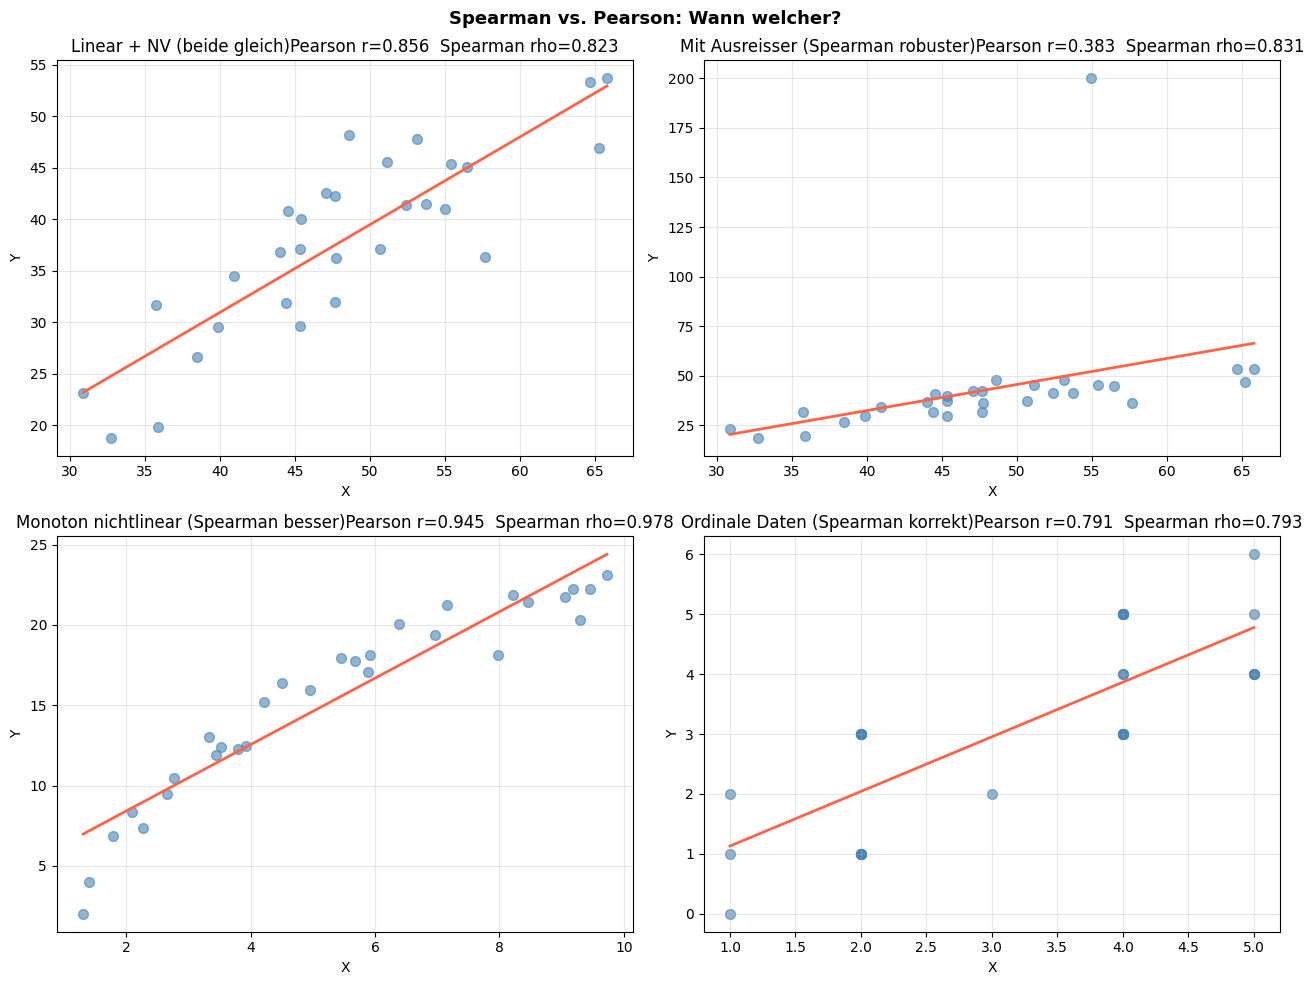

In [6]:
# Spearman vs. Pearson: vier Szenarien
np.random.seed(42)
n_vgl = 30

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Spearman vs. Pearson: Wann welcher?", fontsize=13, fontweight="bold")

szenarien = [
    ("Linear + NV (beide gleich)", None, None),
    ("Mit Ausreisser (Spearman robuster)", None, "ausreisser"),
    ("Monoton nichtlinear (Spearman besser)", None, "nichtlinear"),
    ("Ordinale Daten (Spearman korrekt)", None, "ordinal"),
]

for ax, (titel, _, typ) in zip(axes.flat, szenarien):
    np.random.seed(42)
    x_v = np.random.normal(50, 10, n_vgl)

    if typ == "ausreisser":
        y_v = 0.8*x_v + np.random.normal(0, 5, n_vgl)
        y_v[0] = 200  # starker Ausreisser
    elif typ == "nichtlinear":
        x_v = np.sort(np.random.uniform(1, 10, n_vgl))
        y_v = np.log(x_v) * 10 + np.random.normal(0, 1, n_vgl)
    elif typ == "ordinal":
        x_v = np.random.choice(range(1, 6), n_vgl)
        y_v = x_v + np.random.choice(range(-1, 2), n_vgl)
    else:
        y_v = 0.8*x_v + np.random.normal(0, 5, n_vgl)

    rp2, pp2 = pearsonr(x_v, y_v)
    rs2, ps2 = spearmanr(x_v, y_v)

    ax.scatter(x_v, y_v, color="steelblue", alpha=0.6, s=50)
    m2, b2 = np.polyfit(x_v, y_v, 1)
    xl2 = np.linspace(x_v.min(), x_v.max(), 100)
    ax.plot(xl2, m2*xl2 + b2, color="tomato", linewidth=2)
    ax.set_title(titel + "Pearson r=" + str(round(rp2, 3)) +
                 "  Spearman rho=" + str(round(rs2, 3)))
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# APA-Ausgabe-Funktion
def spearman_apa(x, y, var_x="Variable X", var_y="Variable Y", alpha=0.05):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n_f  = len(x)
    rho_f, p_f = spearmanr(x, y)

    interp = interpret_rho(rho_f)
    richtg = "positiv" if rho_f > 0 else "negativ"
    sig    = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str  = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Spearman-Korrelation: " + var_x + " x " + var_y)
    print("n=" + str(n_f) + "  rho=" + str(round(rho_f, 4)) + "  " + p_str)
    print("Zusammenhang: " + interp + " (" + richtg + ")")
    print("Ergebnis: " + sig)
    print()
    if p_f < alpha:
        print("APA: rs(" + str(n_f-2) + ") = " + str(round(rho_f, 2)) +
              ", " + p_str)
    print()

# numiqo-Hauptbeispiel
spearman_apa(reaktionszeit, alter, "Reaktionszeit", "Alter")
print()

# Weiteres Beispiel: Ordinalskala (Kundenzufriedenheit x Wiederkaufabsicht)
np.random.seed(3)
zufriedenheit = np.random.choice(range(1, 6), 25)
wiederkauf    = zufriedenheit + np.random.choice(range(-1, 2), 25)
wiederkauf    = np.clip(wiederkauf, 1, 5)
spearman_apa(zufriedenheit, wiederkauf, "Kundenzufriedenheit", "Wiederkaufabsicht")

Spearman-Korrelation: Reaktionszeit x Alter
n=8  rho=0.9048  p = .002
Zusammenhang: sehr hohe Korrelation (positiv)
Ergebnis: signifikant

APA: rs(6) = 0.9, p = .002


Spearman-Korrelation: Kundenzufriedenheit x Wiederkaufabsicht
n=25  rho=0.8663  p < .001
Zusammenhang: sehr hohe Korrelation (positiv)
Ergebnis: signifikant

APA: rs(23) = 0.87, p < .001



## 4. Zusammenfassung

```
Spearman-Korrelation – Übersicht
│
├── WAS?
│   Nichtparametrisches Gegenstück zur Pearson-Korrelation
│   Misst MONOTONEN (nicht nur linearen) Zusammenhang
│   Basiert auf RÄNGEN statt Rohdaten
│
├── KERNIDEE
│   Spearman = Pearson auf den Rängen!
│   Formel (ohne Bindungen):
│   rho = 1 - 6*Sum(d_i^2) / (n*(n^2-1))
│   d_i = Rang(x_i) - Rang(y_i)
│
├── SIGNIFIKANZTEST
│   t = rho * sqrt((n-2)/(1-rho^2)),  df = n-2
│   H0: rho = 0  H1: rho != 0
│
├── WANN SPEARMAN?
│   Keine Normalverteilung
│   Ordinales Skalenniveau
│   Ausreisser vorhanden
│   Monotoner, nicht linearer Zusammenhang
│
├── STÄRKE (Kuckartz 2013)
│   |rho| < 0.1:  keine
│   0.1 - 0.3:    gering
│   0.3 - 0.5:    mittel
│   0.5 - 0.7:    hoch
│   0.7 - 1.0:    sehr hoch
│
├── numiqo-BEISPIEL: Reaktionszeit x Alter (n=8)
│   rho=0.9, p=0.002 -> sehr hohe positive Korrelation
│
└── PYTHON
    from scipy.stats import spearmanr
    rho, p = spearmanr(x, y)
```

---
Quelle: [numiqo.de/tutorial/spearman-korrelation](https://numiqo.de/tutorial/spearman-korrelation)